# Comprehensive Adversarial Benchmark: CNN vs Hybrid SNN
This notebook compares the robustness of Standard CNN and Hybrid CSNN across multiple datasets (MNIST, Fashion-MNIST, CIFAR-10) and adversarial attacks (FGSM, PGD, Salt-and-Pepper).

In [2]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os
import sys

# Add root directory to sys.path for local imports
sys.path.append(os.path.abspath(os.path.join('..')))

from models.standard_cnn import StandardCNN
from models.hybrid_snn import HybridCSNN
from attacks.adversarial import pgd_attack, add_salt_and_pepper_noise, get_model_prediction

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## 1. Data Pipeline

In [3]:
def get_dataloaders(name, batch_size=64):
    transform = transforms.Compose([transforms.ToTensor()])
    if name == 'MNIST':
        trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
        testset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
        in_channels, input_size = 1, 28
    elif name == 'FashionMNIST':
        trainset = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
        testset = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)
        in_channels, input_size = 1, 28
    elif name == 'CIFAR10':
        trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
        testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
        in_channels, input_size = 3, 32
    
    trainloader = DataLoader(trainset, batch_size=batch_size, shuffle=True)
    testloader = DataLoader(testset, batch_size=batch_size, shuffle=False)
    return trainloader, testloader, in_channels, input_size

## 2. Training and Evaluation Functions

In [4]:
def train(model, trainloader, epochs=3, is_snn=False):
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    model.train()
    for epoch in range(epochs):
        for data, target in trainloader:
            data, target = data.to(device), target.to(device)
            optimizer.zero_grad()
            output = get_model_prediction(model, data, is_snn)
            loss = torch.nn.functional.cross_entropy(output, target)
            loss.backward()
            optimizer.step()

def evaluate(model, testloader, is_snn=False, attack=None, epsilon=0.0):
    model.eval()
    correct = 0
    total = 0
    # Limit evaluation to first 1000 images for speed during benchmark
    limit = 1000
    count = 0
    
    for data, target in testloader:
        if count >= limit: break
        data, target = data.to(device), target.to(device)
        
        if attack == 'FGSM':
            data.requires_grad = True
            output = get_model_prediction(model, data, is_snn)
            loss = torch.nn.functional.cross_entropy(output, target)
            model.zero_grad()
            loss.backward()
            data = data + epsilon * data.grad.sign()
            data = torch.clamp(data, 0, 1).detach()
        elif attack == 'PGD':
            data = pgd_attack(model, device, data, target, epsilon, alpha=epsilon/4 if epsilon > 0 else 0, num_iter=10, is_snn=is_snn)
        elif attack == 'SP':
            data = add_salt_and_pepper_noise(data, epsilon)
            
        with torch.no_grad():
            output = get_model_prediction(model, data, is_snn)
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()
            total += target.size(0)
            count += target.size(0)
            
    return correct / total

## 3. Benchmark Execution

In [5]:
datasets = ['MNIST', 'FashionMNIST', 'CIFAR10']
epsilons = [0.0, 0.1, 0.2]
attacks = ['Clean', 'FGSM', 'PGD', 'SP']

results = []

for ds_name in datasets:
    print(f"Benchmarking {ds_name}...")
    batch_size = 32 if ds_name == 'CIFAR10' else 64
    trainloader, testloader, in_channels, input_size = get_dataloaders(ds_name, batch_size)
    
    models = {
        'CNN': StandardCNN(in_channels, input_size).to(device),
        'SNN': HybridCSNN(in_channels, input_size).to(device)
    }
    
    for m_name, model in models.items():
        print(f"  Training {m_name}...")
        is_snn = (m_name == 'SNN')
        train(model, trainloader, epochs=2, is_snn=is_snn)
        
        for atk in attacks:
            if atk == 'Clean':
                acc = evaluate(model, testloader, is_snn)
                results.append({'Dataset': ds_name, 'Model': m_name, 'Attack': atk, 'Epsilon': 0.0, 'Accuracy': acc})
            else:
                for eps in epsilons[1:]:
                    acc = evaluate(model, testloader, is_snn, atk, eps)
                    results.append({'Dataset': ds_name, 'Model': m_name, 'Attack': atk, 'Epsilon': eps, 'Accuracy': acc})

df = pd.DataFrame(results)
df.to_csv('benchmark_results.csv', index=False)
print("Benchmark complete.")

Benchmarking MNIST...
  Training CNN...
  Training SNN...
Benchmarking FashionMNIST...
  Training CNN...
  Training SNN...
Benchmarking CIFAR10...


c:\Users\nikol\Desktop\csnn-adversarial-attacks\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


  Training CNN...
  Training SNN...
Benchmark complete.


## 4. Visualization and Analysis

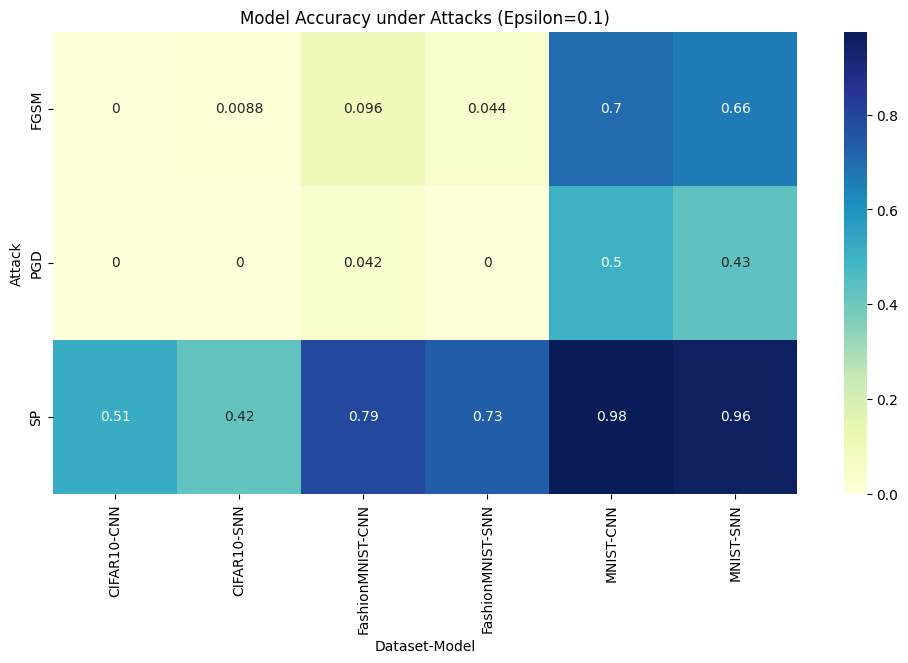

In [6]:
# Filter for specific epsilon for heatmap visualization
heatmap_data = df[df['Epsilon'] == 0.1].pivot_table(index='Attack', columns=['Dataset', 'Model'], values='Accuracy')

plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, annot=True, cmap='YlGnBu')
plt.title('Model Accuracy under Attacks (Epsilon=0.1)')
plt.show()

In [7]:
# Robustness Score Metric
def calculate_robustness(df):
    robustness_scores = []
    for ds in df['Dataset'].unique():
        for atk in df[df['Attack'] != 'Clean']['Attack'].unique():
            cnn_clean = df[(df['Dataset']==ds) & (df['Model']=='CNN') & (df['Attack']=='Clean')]['Accuracy'].values[0]
            snn_clean = df[(df['Dataset']==ds) & (df['Model']=='SNN') & (df['Attack']=='Clean')]['Accuracy'].values[0]
            
            cnn_adv = df[(df['Dataset']==ds) & (df['Model']=='CNN') & (df['Attack']==atk) & (df['Epsilon']==0.1)]['Accuracy'].values[0]
            snn_adv = df[(df['Dataset']==ds) & (df['Model']=='SNN') & (df['Attack']==atk) & (df['Epsilon']==0.1)]['Accuracy'].values[0]
            
            cnn_drop = (cnn_clean - cnn_adv) / cnn_clean
            snn_drop = (snn_clean - snn_adv) / snn_clean
            
            # Score > 1 means SNN is more robust (lower relative drop)
            score = cnn_drop / snn_drop if snn_drop > 0 else 1.0
            robustness_scores.append({'Dataset': ds, 'Attack': atk, 'Robustness_Ratio': score})
    
    return pd.DataFrame(robustness_scores)

score_df = calculate_robustness(df)
print("Robustness Ratio (SNN Robustness / CNN Robustness):")
print(score_df)

Robustness Ratio (SNN Robustness / CNN Robustness):
        Dataset Attack  Robustness_Ratio
0         MNIST   FGSM          0.875758
1         MNIST    PGD          0.867958
2         MNIST     SP          0.275862
3  FashionMNIST   FGSM          0.940673
4  FashionMNIST    PGD          0.953514
5  FashionMNIST     SP          0.717811
6       CIFAR10   FGSM          1.018519
7       CIFAR10    PGD          1.000000
8       CIFAR10     SP          0.778404
